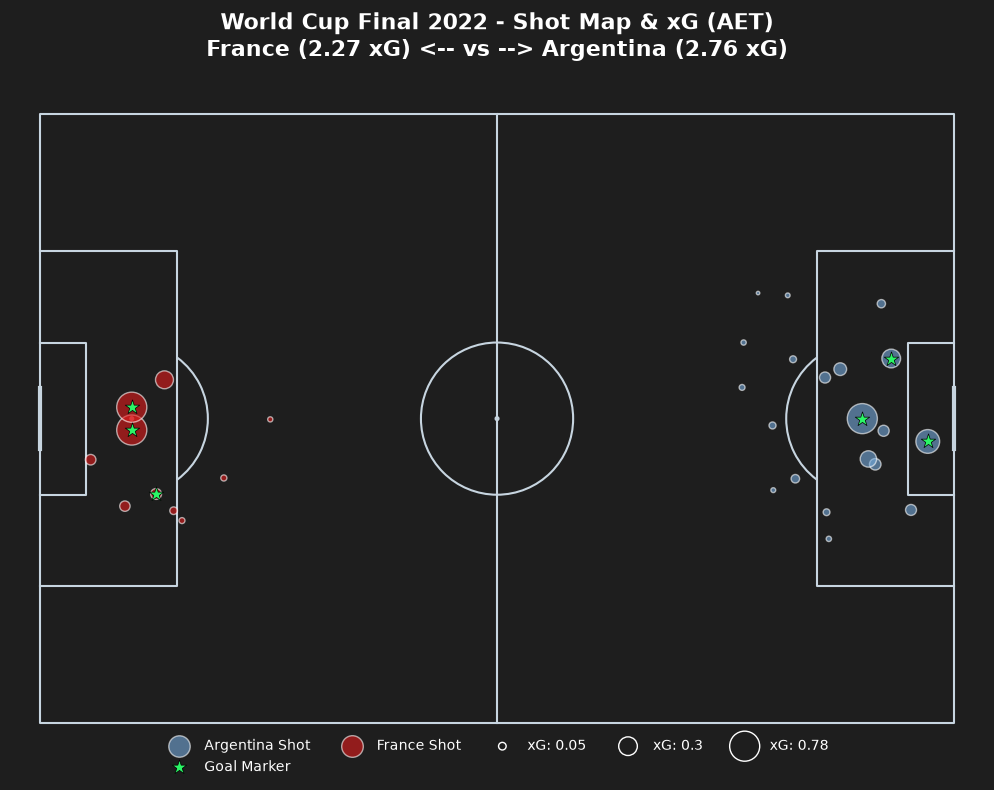

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch
from statsbombpy import sb

# 1. Изтегляне на събитията
match_events = sb.events(match_id=3869685)

# 2. Филтриране само за редовно време и продължения (без дузпите след мача)
shots = match_events[
    (match_events["type"] == "Shot") & (match_events["period"] <= 4)
].copy()

shots["x"] = [loc[0] for loc in shots["location"]]
shots["y"] = [loc[1] for loc in shots["location"]]

# Разделяне по отбори
arg_shots = shots[shots["team"] == "Argentina"].copy()
fra_shots = shots[shots["team"] == "France"].copy()

# Jittering за 2-те дузпи на Франция
fra_penalties = fra_shots[fra_shots["shot_type"] == "Penalty"]
if len(fra_penalties) > 1:
    offset = np.linspace(-1.5, 1.5, len(fra_penalties))
    fra_shots.loc[fra_shots["shot_type"] == "Penalty", "y"] += offset

# Огледално обръщане за Франция
fra_shots["x"] = 120 - fra_shots["x"]
fra_shots["y"] = 80 - fra_shots["y"]

# Разделяне на Голове и Пропуски
arg_goals = arg_shots[arg_shots["shot_outcome"] == "Goal"]
arg_non_goals = arg_shots[arg_shots["shot_outcome"] != "Goal"]

fra_goals = fra_shots[fra_shots["shot_outcome"] == "Goal"]
fra_non_goals = fra_shots[fra_shots["shot_outcome"] != "Goal"]

# Чертаене
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#1e1e1e",
    line_color="#c7d5e0",
    linewidth=1.5,
)
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor("#1e1e1e")

# --- АРЖЕНТИНА ---
# Всеки удар (вкл. головете) се чертае първо като КРЪГ с xG размер
pitch.scatter(
    arg_shots.x,
    arg_shots.y,
    s=arg_shots["shot_statsbomb_xg"] * 600,
    color="#75aadb",
    alpha=0.6,
    edgecolors="white",
    linewidth=1,
    ax=ax,
    label="Argentina Shot",
)
# Върху головете слагаме малка зелена маркер-звезда
pitch.scatter(
    arg_goals.x,
    arg_goals.y,
    s=120,
    color="#2bf666",
    marker="*",
    edgecolors="black",
    linewidth=0.5,
    ax=ax,
    label="Goal Marker",
)

# --- ФРАНЦИЯ ---
pitch.scatter(
    fra_shots.x,
    fra_shots.y,
    s=fra_shots["shot_statsbomb_xg"] * 600,
    color="#e11c1c",
    alpha=0.6,
    edgecolors="white",
    linewidth=1,
    ax=ax,
    label="France Shot",
)
pitch.scatter(
    fra_goals.x,
    fra_goals.y,
    s=120,
    color="#2bf666",
    marker="*",
    edgecolors="black",
    linewidth=0.5,
    ax=ax,
)

# Легенда за xG размерите (извън терена)
for xg_val in [0.05, 0.30, 0.78]:
    pitch.scatter(
        125,
        125,
        s=xg_val * 600,
        color="none",
        edgecolors="white",
        ax=ax,
        label=f"xG: {xg_val}",
    )

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    facecolor="#1e1e1e",
    edgecolor="none",
    labelcolor="white",
    fontsize=10,
)

arg_xg = arg_shots["shot_statsbomb_xg"].sum()
fra_xg = fra_shots["shot_statsbomb_xg"].sum()

plt.title(
    f"World Cup Final 2022 - Shot Map & xG (AET)\nFrance ({fra_xg:.2f} xG) <-- vs --> Argentina ({arg_xg:.2f} xG)",
    color="white",
    fontsize=16,
    pad=20,
    fontweight="bold",
)

plt.savefig(
    "wc2022_final_shotmap_layered.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#1e1e1e",
)
plt.show()